In [27]:
# 安装必要的包
!pip install tslearn
!pip install baostock
!pip install tqdm



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [38]:
# 导入模块
import warnings
warnings.filterwarnings("ignore")  # 全局忽略警告

import pandas as pd
import numpy as np
import baostock as bs
from tqdm import tqdm

from tslearn.utils import to_time_series_dataset
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans

import matplotlib.pyplot as plt
from math import ceil, sqrt


In [39]:
# 读取成分股文件
constituent_stock = pd.read_excel("多行业成分股合并表.xlsx")
print(f"✅ 原始成分股数量：{len(constituent_stock)}")

# 获取所有成分股代码和行业信息
all_stock_list = constituent_stock['代码'].tolist()
code_to_industry = dict(zip(constituent_stock['代码'], constituent_stock['行业']))

# 从 Baostock 拉取收盘价数据（按周频）
bs.login()

all_data_list = []
valid_codes = []
bad_codes = []

for code in tqdm(all_stock_list):
    rs = bs.query_history_k_data_plus(
        code,
        "date,close",
        start_date='2023-01-01',
        end_date='2025-01-01',
        frequency="w",
        adjustflag="3"
    )

    if rs.error_code == '0':
        df = pd.DataFrame(rs.data, columns=rs.fields)
        df['close'] = pd.to_numeric(df['close'], errors='coerce')
        close_list = df['close'].dropna().tolist()

        if len(close_list) >= 100:
            all_data_list.append(close_list)
            valid_codes.append(code)
        else:
            bad_codes.append(code)
    else:
        print(f"❌ {code} 查询失败：{rs.error_msg}")
        bad_codes.append(code)

bs.logout()
print(f"⚠️ 无效样本数量：{len(bad_codes)}")
print(f"✅ 有效样本数量：{len(valid_codes)}")

# 构建有效样本 DataFrame（带行业信息）
valid_df = pd.DataFrame({
    '代码': valid_codes,
    '收盘价序列': all_data_list,
    '行业': [code_to_industry.get(code, '未知') for code in valid_codes]
})

# 统计清洗后的行业分布
industry_counts = valid_df['行业'].value_counts()
print("📊 清洗后各行业分布：")
print(industry_counts)



✅ 原始成分股数量：396
login success!


100%|██████████| 396/396 [00:23<00:00, 16.54it/s]

logout success!
⚠️ 无效样本数量：31
✅ 有效样本数量：365
📊 清洗后各行业分布：
行业
半导体      129
食品饮料     110
房地产开发     84
银行        42
Name: count, dtype: int64


In [41]:
# 每行业最多保留 N 支股票
sample_per_industry = 40

# 按行业抽样
sampled_df = valid_df.groupby('行业').apply(
    lambda x: x.sample(n=sample_per_industry, random_state=20) if len(x) >= sample_per_industry else x
).reset_index(drop=True)

print(f"✅ 抽样后总样本数量：{len(sampled_df)}")
print("📊 抽样后各行业数量：")
print(sampled_df['行业'].value_counts())


✅ 抽样后总样本数量：160
📊 抽样后各行业数量：
行业
半导体      40
房地产开发    40
银行       40
食品饮料     40
Name: count, dtype: int64


In [42]:
# 提取清洗后时间序列并标准化
cleaned_all_data_list = sampled_df['收盘价序列'].tolist()
cleaned_constituent_stock_list = sampled_df['代码'].tolist()

X_train = to_time_series_dataset(cleaned_all_data_list)
scaler = TimeSeriesScalerMeanVariance()
X_train = scaler.fit_transform(X_train)

print("✅ 预处理后的形状：", X_train.shape)


✅ 预处理后的形状： (160, 101, 1)


In [43]:
# 使用 Soft-DTW KMeans 进行聚类
seed = 12
n_clusters = 4
gamma = 0.1

print("Soft-DTW k-means 聚类中...")
sdtw_km = TimeSeriesKMeans(
    n_clusters=n_clusters,
    metric="softdtw",
    metric_params={"gamma": gamma},
    random_state=seed,
    verbose=True
)

y_pred = sdtw_km.fit_predict(X_train)
print("✅ 聚类完成！")


Soft-DTW k-means 聚类中...
203.029 --> 63.911 --> 60.798 --> 59.789 --> 56.267 --> 54.489 --> 52.736 --> 52.566 --> 52.589 --> 52.619 --> 52.601 --> 52.550 --> 52.557 --> 52.517 --> 52.557 --> 52.393 --> 52.437 --> 52.519 --> 52.463 --> 52.470 --> 52.536 --> 52.456 --> 52.509 --> 52.457 --> 52.499 --> 52.462 --> 52.495 --> 52.458 --> 52.519 --> 52.463 --> 52.528 --> 52.381 --> 52.779 --> 52.778 --> 52.818 --> 52.769 --> 52.772 --> 52.843 --> 52.748 --> 52.797 --> 52.582 --> 52.637 --> 52.484 --> 52.603 --> 52.473 --> 52.515 --> 52.550 --> 52.515 --> 52.554 --> 52.486 --> 
✅ 聚类完成！


In [33]:
from tslearn.metrics import soft_dtw
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
import numpy as np

# ✅ 计算聚类评估指标
print("\n📊 计算聚类评估指标...")

# ✅ 计算 Pairwise Soft-DTW Distance Matrix
print("Computing Soft-DTW pairwise distance matrix...")
n_samples = X_train.shape[0]
pairwise_distances = np.zeros((n_samples, n_samples))

for i in range(n_samples):
    for j in range(i + 1, n_samples):
        dist = soft_dtw(X_train[i], X_train[j], gamma=gamma)
        pairwise_distances[i, j] = dist
        pairwise_distances[j, i] = dist  # 对称

# ⭐ 新增这行，保证矩阵都是非负数
pairwise_distances = np.maximum(pairwise_distances, 0)

print("✅ Soft-DTW 距离矩阵计算完成！")


# 2. Silhouette Score（基于Soft-DTW距离）
sil_score = silhouette_score(pairwise_distances, y_pred, metric="precomputed")
print(f"Silhouette Score (based on Soft-DTW distances): {sil_score:.4f}")

# 3. WSS（Within-Cluster Sum of Squares）
print("Computing Within-Cluster Sum of Soft-DTW Distances (WSS)...")
wss = 0
for idx, x in enumerate(X_train):
    center = sdtw_km.cluster_centers_[y_pred[idx]]
    wss += soft_dtw(x, center, gamma=gamma)
print(f"Within-Cluster Sum of Distances (WSS): {wss:.4f}")

# 4. Davies-Bouldin Index (直接基于特征向量，注意是原数据）
X_train_flat = X_train.reshape(X_train.shape[0], -1)
dbi_score = davies_bouldin_score(X_train_flat, y_pred)
print(f"Davies–Bouldin Index (DBI): {dbi_score:.4f}")

print("✅ 聚类指标计算完成！")



📊 计算聚类评估指标...
Computing Soft-DTW pairwise distance matrix...
✅ Soft-DTW 距离矩阵计算完成！
Silhouette Score (based on Soft-DTW distances): 0.5116
Computing Within-Cluster Sum of Soft-DTW Distances (WSS)...
Within-Cluster Sum of Distances (WSS): 305.8795
Davies–Bouldin Index (DBI): 1.9608
✅ 聚类指标计算完成！


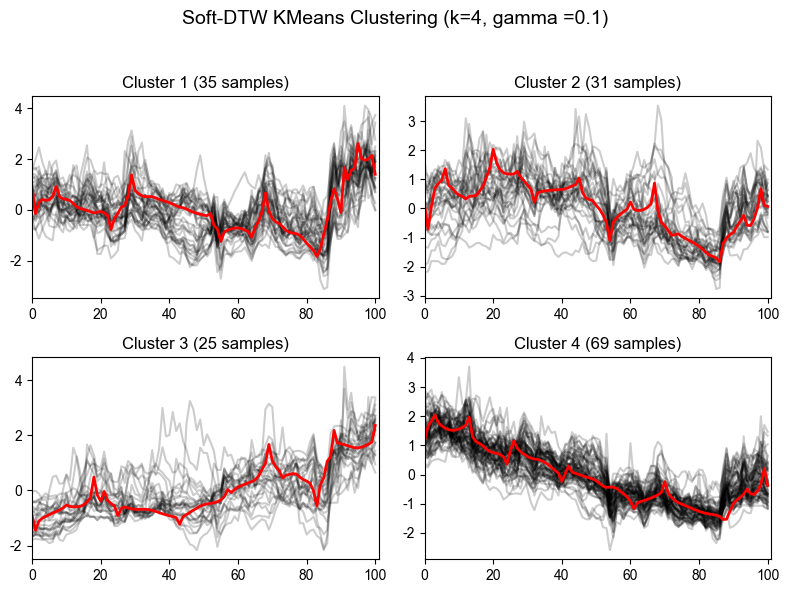

In [34]:
# 绘制每个聚类的时间序列走势

n_cols = ceil(sqrt(n_clusters))
n_rows = ceil(n_clusters / n_cols)

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for yi in range(n_clusters):
    plt.subplot(n_rows, n_cols, yi + 1)
    cluster_mask = (y_pred == yi)
    cluster_size = np.sum(cluster_mask)

    for xx in X_train[cluster_mask]:
        plt.plot(xx.ravel(), "k-", alpha=0.2)

    plt.plot(sdtw_km.cluster_centers_[yi].ravel(), "r-", linewidth=2)
    plt.xlim(0, X_train.shape[1])
    plt.title(f"Cluster {yi + 1} ({cluster_size} samples)")

plt.suptitle(f"Soft-DTW KMeans Clustering (k={n_clusters}, gamma ={gamma})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


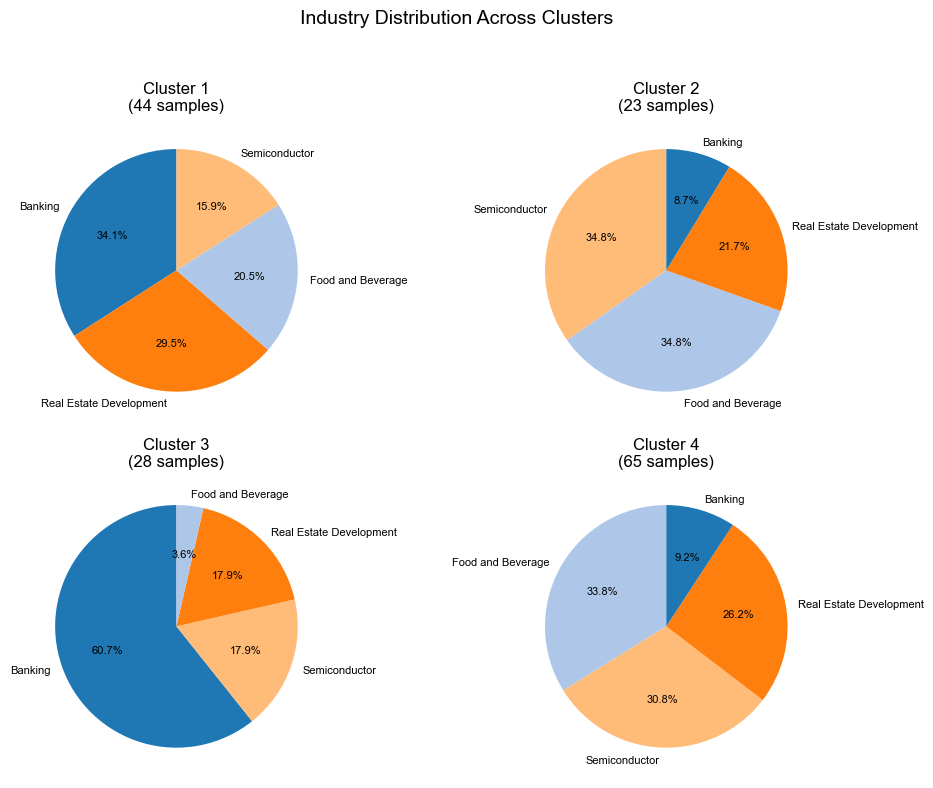

In [35]:
import matplotlib.pyplot as plt
from math import ceil, sqrt
import pandas as pd

# ✅ 设置英文字体
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# ✅ 行业中文到英文的映射
industry_translation = {
    '半导体': 'Semiconductor',
    '银行': 'Banking',
    '房地产开发': 'Real Estate Development',
    '食品饮料': 'Food and Beverage',
    '其他': 'Others'
}

# ✅ 替换中文行业为英文行业
cluster_df['industry_group_en'] = cluster_df['industry_group'].map(industry_translation)

# ✅ 重新生成所有英文标签的配色
all_industries_en = sorted(cluster_df['industry_group_en'].unique())
color_palette = plt.cm.tab20.colors
industry_to_color_en = {industry: color_palette[i % len(color_palette)] for i, industry in enumerate(all_industries_en)}

# ✅ 重新绘制英文版饼图
n_cols = ceil(sqrt(n_clusters))
n_rows = ceil(n_clusters / n_cols)

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i in range(n_clusters):
    plt.subplot(n_rows, n_cols, i + 1)
    group_counts = cluster_df.loc[cluster_df['cluster'] == i, 'industry_group_en'].value_counts()
    colors = [industry_to_color_en[industry] for industry in group_counts.index]

    plt.pie(group_counts, labels=group_counts.index, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 8}, colors=colors)
    plt.title(f"Cluster {i + 1}\n({group_counts.sum()} samples)")

plt.suptitle("Industry Distribution Across Clusters", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [36]:
# 重新读取行业与名称信息，并清洗同步
constituent_stock_full = pd.read_excel("多行业成分股合并表.xlsx")
sampled_constituent_stock = constituent_stock_full[constituent_stock_full['代码'].isin(cleaned_constituent_stock_list)].reset_index(drop=True)

# 构建聚类结果 DataFrame
result_df = pd.DataFrame({
    '代码': cleaned_constituent_stock_list,
    '聚类': y_pred
})

# 合并名称和行业
result_df = result_df.merge(sampled_constituent_stock[['代码', '名称', '行业']], on='代码', how='left')

# 保存为 CSV 文件
result_df.to_csv("聚类结果.csv", index=False, encoding='utf-8-sig')

print("✅ 聚类结果已保存为：聚类结果.csv")
print(result_df)


✅ 聚类结果已保存为：聚类结果.csv
            代码  聚类    名称    行业
0    sz.301369   3  联动科技   半导体
1    sh.688508   3   芯朋微   半导体
2    sh.688362   1  甬矽电子   半导体
3    sh.688259   3  创耀科技   半导体
4    sz.300223   1  北京君正   半导体
..         ...  ..   ...   ...
155  sz.002597   3  金禾实业  食品饮料
156  sz.002661   3  克明食品  食品饮料
157  sz.002695   3   煌上煌  食品饮料
158  sz.002286   3   保龄宝  食品饮料
159  sz.000639   3  西王食品  食品饮料

[160 rows x 4 columns]


In [37]:
# ✅ 基于行业标签的时间序列统计（平均值、标准差、最大值、最小值、中位数、极差）

# 添加收盘价序列（如果还没有加的话）
result_df['收盘价序列'] = cleaned_all_data_list


# 定义计算函数
def compute_industry_stats(series_list):
    flat_values = pd.Series([v for s in series_list for v in s if pd.notna(v)])
    return {
        '平均值': round(flat_values.mean(), 4),
        '标准差': round(flat_values.std(), 4),
        '最大值': round(flat_values.max(), 4),
        '最小值': round(flat_values.min(), 4),
        '中位数': round(flat_values.median(), 4),
        '极差': round(flat_values.max() - flat_values.min(), 4)
    }


# 分组计算
industry_stats = result_df.groupby('行业')['收盘价序列'].apply(compute_industry_stats).apply(pd.Series)

# 打印输出
print("\n📊 按行业标签统计的时间序列特征（含极差）：")
print(industry_stats)

# 保存为 CSV 文件
industry_stats.to_csv("行业统计特征_六维.csv", encoding='utf-8-sig')
print("✅ 行业统计结果已保存为：行业统计特征_六维.csv")



📊 按行业标签统计的时间序列特征（含极差）：
                  0
行业                 
半导体   平均值   51.9527
      标准差   54.1063
      最大值  430.6400
      最小值    7.8400
      中位数   33.5300
      极差   422.8000
房地产开发 平均值    5.6048
      标准差    3.9693
      最大值   32.8600
      最小值    1.1600
      中位数    4.2300
      极差    31.7000
银行    平均值    7.1330
      标准差    6.0501
      最大值   41.0500
      最小值    1.6300
      中位数    5.4750
      极差    39.4200
食品饮料  平均值   18.5193
      标准差   20.0584
      最大值  173.3500
      最小值    2.2300
      中位数   13.6450
      极差   171.1200
✅ 行业统计结果已保存为：行业统计特征_六维.csv
